In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words[:5]:
    print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix= stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


In [6]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [7]:
X, Y

(tensor([[ 0,  0,  0],
         [ 0,  0,  5],
         [ 0,  5, 13],
         [ 5, 13, 13],
         [13, 13,  1],
         [ 0,  0,  0],
         [ 0,  0, 15],
         [ 0, 15, 12],
         [15, 12,  9],
         [12,  9, 22],
         [ 9, 22,  9],
         [22,  9,  1],
         [ 0,  0,  0],
         [ 0,  0,  1],
         [ 0,  1, 22],
         [ 1, 22,  1],
         [ 0,  0,  0],
         [ 0,  0,  9],
         [ 0,  9, 19],
         [ 9, 19,  1],
         [19,  1,  2],
         [ 1,  2,  5],
         [ 2,  5, 12],
         [ 5, 12, 12],
         [12, 12,  1],
         [ 0,  0,  0],
         [ 0,  0, 19],
         [ 0, 19, 15],
         [19, 15, 16],
         [15, 16,  8],
         [16,  8,  9],
         [ 8,  9,  1]]),
 tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
          1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0]))

In [8]:
# embedding lookup table C:
# in the paper: 17K words in 30 dim spqce, Here as we have only 27, ok to start with a 2 dim embedding


In [9]:
C = torch.randn((27, 2))

In [10]:
C

tensor([[ 1.0067,  1.2935],
        [ 0.7678,  0.8097],
        [-1.7223,  0.1916],
        [ 1.2832, -0.2340],
        [-1.2866, -0.6596],
        [-0.0156, -0.7280],
        [ 0.9506,  0.1337],
        [ 0.1159, -1.5134],
        [-0.1627,  0.5217],
        [-0.4673,  2.2752],
        [-1.6793,  0.9094],
        [ 0.4386,  1.1423],
        [-0.6653, -1.7049],
        [-0.2125,  0.7867],
        [ 0.1182,  0.0206],
        [ 0.5470, -2.2773],
        [-1.1050, -0.2592],
        [ 0.2365, -0.2633],
        [-1.2147, -0.6842],
        [ 0.8699,  0.3473],
        [-1.5716,  0.0544],
        [ 0.0500, -1.3965],
        [-1.2954,  2.3514],
        [ 2.2264,  0.5087],
        [ 0.2014,  1.0939],
        [ 1.2686, -0.2398],
        [-0.7371,  1.4301]])

In [11]:
C.shape

torch.Size([27, 2])

In [12]:
# before embedding all integers inside the input X, we make an example with 5
# one way is to index 5 in the lookup table C, getting the 5th row
C[5]

tensor([-0.0156, -0.7280])

In [13]:
# the other way is to use one-hot encoding. Output is identical. All zero masking out all the rows but the 5th
F.one_hot(torch.tensor(5), num_classes=27).float() @ C

tensor([-0.0156, -0.7280])

In [14]:
 # using indexing to do embedding is equal to use one-hot encoding. Here we use index as it is much faster.
# this can be seen as first layer of NN.

In [15]:
emb = C[X]

In [16]:
emb.shape

torch.Size([32, 3, 2])

In [17]:
X, C, emb

(tensor([[ 0,  0,  0],
         [ 0,  0,  5],
         [ 0,  5, 13],
         [ 5, 13, 13],
         [13, 13,  1],
         [ 0,  0,  0],
         [ 0,  0, 15],
         [ 0, 15, 12],
         [15, 12,  9],
         [12,  9, 22],
         [ 9, 22,  9],
         [22,  9,  1],
         [ 0,  0,  0],
         [ 0,  0,  1],
         [ 0,  1, 22],
         [ 1, 22,  1],
         [ 0,  0,  0],
         [ 0,  0,  9],
         [ 0,  9, 19],
         [ 9, 19,  1],
         [19,  1,  2],
         [ 1,  2,  5],
         [ 2,  5, 12],
         [ 5, 12, 12],
         [12, 12,  1],
         [ 0,  0,  0],
         [ 0,  0, 19],
         [ 0, 19, 15],
         [19, 15, 16],
         [15, 16,  8],
         [16,  8,  9],
         [ 8,  9,  1]]),
 tensor([[ 1.0067,  1.2935],
         [ 0.7678,  0.8097],
         [-1.7223,  0.1916],
         [ 1.2832, -0.2340],
         [-1.2866, -0.6596],
         [-0.0156, -0.7280],
         [ 0.9506,  0.1337],
         [ 0.1159, -1.5134],
         [-0.1627,  0.5217],
 

In [18]:
emb

tensor([[[ 1.0067,  1.2935],
         [ 1.0067,  1.2935],
         [ 1.0067,  1.2935]],

        [[ 1.0067,  1.2935],
         [ 1.0067,  1.2935],
         [-0.0156, -0.7280]],

        [[ 1.0067,  1.2935],
         [-0.0156, -0.7280],
         [-0.2125,  0.7867]],

        [[-0.0156, -0.7280],
         [-0.2125,  0.7867],
         [-0.2125,  0.7867]],

        [[-0.2125,  0.7867],
         [-0.2125,  0.7867],
         [ 0.7678,  0.8097]],

        [[ 1.0067,  1.2935],
         [ 1.0067,  1.2935],
         [ 1.0067,  1.2935]],

        [[ 1.0067,  1.2935],
         [ 1.0067,  1.2935],
         [ 0.5470, -2.2773]],

        [[ 1.0067,  1.2935],
         [ 0.5470, -2.2773],
         [-0.6653, -1.7049]],

        [[ 0.5470, -2.2773],
         [-0.6653, -1.7049],
         [-0.4673,  2.2752]],

        [[-0.6653, -1.7049],
         [-0.4673,  2.2752],
         [-1.2954,  2.3514]],

        [[-0.4673,  2.2752],
         [-1.2954,  2.3514],
         [-0.4673,  2.2752]],

        [[-1.2954,  2

In [19]:
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1)

tensor([[ 1.0067,  1.2935,  1.0067,  1.2935,  1.0067,  1.2935],
        [ 1.0067,  1.2935,  1.0067,  1.2935, -0.0156, -0.7280],
        [ 1.0067,  1.2935, -0.0156, -0.7280, -0.2125,  0.7867],
        [-0.0156, -0.7280, -0.2125,  0.7867, -0.2125,  0.7867],
        [-0.2125,  0.7867, -0.2125,  0.7867,  0.7678,  0.8097],
        [ 1.0067,  1.2935,  1.0067,  1.2935,  1.0067,  1.2935],
        [ 1.0067,  1.2935,  1.0067,  1.2935,  0.5470, -2.2773],
        [ 1.0067,  1.2935,  0.5470, -2.2773, -0.6653, -1.7049],
        [ 0.5470, -2.2773, -0.6653, -1.7049, -0.4673,  2.2752],
        [-0.6653, -1.7049, -0.4673,  2.2752, -1.2954,  2.3514],
        [-0.4673,  2.2752, -1.2954,  2.3514, -0.4673,  2.2752],
        [-1.2954,  2.3514, -0.4673,  2.2752,  0.7678,  0.8097],
        [ 1.0067,  1.2935,  1.0067,  1.2935,  1.0067,  1.2935],
        [ 1.0067,  1.2935,  1.0067,  1.2935,  0.7678,  0.8097],
        [ 1.0067,  1.2935,  0.7678,  0.8097, -1.2954,  2.3514],
        [ 0.7678,  0.8097, -1.2954,  2.3

In [20]:
W1 = torch.randn((6, 100)) 
b1 = torch.randn(100)
# hidden layer construction - initialized with random parameters
# 6 is the number of inputs given from 3 vectors projected on 2D spaced (2-dim embedding)
# 100 is the number of neurons and we can chose by us 

In [21]:
# problem: emb @ W1 + b1 cannot be done as emb is torch.Size([32, 3, 2]) and W1 is (6, 100)
# in emb, 3 vector concatenated (torch.cat)so that emb becomes (32, 6)
# the definition above is not generic and need to be rewritten if block size changes
# a generic espression is the following:
# len(torch.unbind(emb,1)) is 3 -> returning 3 tensors: one for index 0, one for index 1 and one for index 2
#torch.cat(torch.unbind(emb,1), 1).shape
torch.unbind(emb,1)



(tensor([[ 1.0067,  1.2935],
         [ 1.0067,  1.2935],
         [ 1.0067,  1.2935],
         [-0.0156, -0.7280],
         [-0.2125,  0.7867],
         [ 1.0067,  1.2935],
         [ 1.0067,  1.2935],
         [ 1.0067,  1.2935],
         [ 0.5470, -2.2773],
         [-0.6653, -1.7049],
         [-0.4673,  2.2752],
         [-1.2954,  2.3514],
         [ 1.0067,  1.2935],
         [ 1.0067,  1.2935],
         [ 1.0067,  1.2935],
         [ 0.7678,  0.8097],
         [ 1.0067,  1.2935],
         [ 1.0067,  1.2935],
         [ 1.0067,  1.2935],
         [-0.4673,  2.2752],
         [ 0.8699,  0.3473],
         [ 0.7678,  0.8097],
         [-1.7223,  0.1916],
         [-0.0156, -0.7280],
         [-0.6653, -1.7049],
         [ 1.0067,  1.2935],
         [ 1.0067,  1.2935],
         [ 1.0067,  1.2935],
         [ 0.8699,  0.3473],
         [ 0.5470, -2.2773],
         [-1.1050, -0.2592],
         [-0.1627,  0.5217]]),
 tensor([[ 1.0067,  1.2935],
         [ 1.0067,  1.2935],
         [-0

In [22]:
torch.cat(torch.unbind(emb,1), 1)

tensor([[ 1.0067,  1.2935,  1.0067,  1.2935,  1.0067,  1.2935],
        [ 1.0067,  1.2935,  1.0067,  1.2935, -0.0156, -0.7280],
        [ 1.0067,  1.2935, -0.0156, -0.7280, -0.2125,  0.7867],
        [-0.0156, -0.7280, -0.2125,  0.7867, -0.2125,  0.7867],
        [-0.2125,  0.7867, -0.2125,  0.7867,  0.7678,  0.8097],
        [ 1.0067,  1.2935,  1.0067,  1.2935,  1.0067,  1.2935],
        [ 1.0067,  1.2935,  1.0067,  1.2935,  0.5470, -2.2773],
        [ 1.0067,  1.2935,  0.5470, -2.2773, -0.6653, -1.7049],
        [ 0.5470, -2.2773, -0.6653, -1.7049, -0.4673,  2.2752],
        [-0.6653, -1.7049, -0.4673,  2.2752, -1.2954,  2.3514],
        [-0.4673,  2.2752, -1.2954,  2.3514, -0.4673,  2.2752],
        [-1.2954,  2.3514, -0.4673,  2.2752,  0.7678,  0.8097],
        [ 1.0067,  1.2935,  1.0067,  1.2935,  1.0067,  1.2935],
        [ 1.0067,  1.2935,  1.0067,  1.2935,  0.7678,  0.8097],
        [ 1.0067,  1.2935,  0.7678,  0.8097, -1.2954,  2.3514],
        [ 0.7678,  0.8097, -1.2954,  2.3

In [23]:
# more efficient way to do it by using a view: there is no memory change of the tensor
# the a.storage() stays the same. Changing only attributes to represent the tensor

In [24]:
a = torch.arange(18)
a

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

In [25]:
a.shape

torch.Size([18])

In [26]:
a.view(2,9)

tensor([[ 0,  1,  2,  3,  4,  5,  6,  7,  8],
        [ 9, 10, 11, 12, 13, 14, 15, 16, 17]])

In [27]:
a.storage()

/var/folders/6x/g47f8b917pv3w7c2_dccwxw40000gn/T/ipykernel_3266/214256462.py:1: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  a.storage()


 0
 1
 2
 3
 4
 5
 6
 7
 8
 9
 10
 11
 12
 13
 14
 15
 16
 17
[torch.storage.TypedStorage(dtype=torch.int64, device=cpu) of size 18]

In [28]:
a.untyped_storage()

 0
 0
 0
 0
 0
 0
 0
 0
 1
 0
 0
 0
 0
 0
 0
 0
 2
 0
 0
 0
 0
 0
 0
 0
 3
 0
 0
 0
 0
 0
 0
 0
 4
 0
 0
 0
 0
 0
 0
 0
 5
 0
 0
 0
 0
 0
 0
 0
 6
 0
 0
 0
 0
 0
 0
 0
 7
 0
 0
 0
 0
 0
 0
 0
 8
 0
 0
 0
 0
 0
 0
 0
 9
 0
 0
 0
 0
 0
 0
 0
 10
 0
 0
 0
 0
 0
 0
 0
 11
 0
 0
 0
 0
 0
 0
 0
 12
 0
 0
 0
 0
 0
 0
 0
 13
 0
 0
 0
 0
 0
 0
 0
 14
 0
 0
 0
 0
 0
 0
 0
 15
 0
 0
 0
 0
 0
 0
 0
 16
 0
 0
 0
 0
 0
 0
 0
 17
 0
 0
 0
 0
 0
 0
 0
[torch.storage.UntypedStorage(device=cpu) of size 144]

In [29]:
emb.shape

torch.Size([32, 3, 2])

In [30]:
emb.view(32,6)

tensor([[ 1.0067,  1.2935,  1.0067,  1.2935,  1.0067,  1.2935],
        [ 1.0067,  1.2935,  1.0067,  1.2935, -0.0156, -0.7280],
        [ 1.0067,  1.2935, -0.0156, -0.7280, -0.2125,  0.7867],
        [-0.0156, -0.7280, -0.2125,  0.7867, -0.2125,  0.7867],
        [-0.2125,  0.7867, -0.2125,  0.7867,  0.7678,  0.8097],
        [ 1.0067,  1.2935,  1.0067,  1.2935,  1.0067,  1.2935],
        [ 1.0067,  1.2935,  1.0067,  1.2935,  0.5470, -2.2773],
        [ 1.0067,  1.2935,  0.5470, -2.2773, -0.6653, -1.7049],
        [ 0.5470, -2.2773, -0.6653, -1.7049, -0.4673,  2.2752],
        [-0.6653, -1.7049, -0.4673,  2.2752, -1.2954,  2.3514],
        [-0.4673,  2.2752, -1.2954,  2.3514, -0.4673,  2.2752],
        [-1.2954,  2.3514, -0.4673,  2.2752,  0.7678,  0.8097],
        [ 1.0067,  1.2935,  1.0067,  1.2935,  1.0067,  1.2935],
        [ 1.0067,  1.2935,  1.0067,  1.2935,  0.7678,  0.8097],
        [ 1.0067,  1.2935,  0.7678,  0.8097, -1.2954,  2.3514],
        [ 0.7678,  0.8097, -1.2954,  2.3

In [31]:
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
h

# emb.view(32,6) can be replaced by emb.view(-1,6) -> torch understand the size automatically

tensor([[-0.8534,  0.9974, -0.9998,  ...,  0.6859, -0.6421, -0.9880],
        [-0.8178,  0.4056, -0.9954,  ..., -0.9966, -0.1546, -0.5742],
        [ 0.8104,  0.5090, -0.9896,  ...,  0.9496,  0.9749, -0.8764],
        ...,
        [ 0.9863, -0.4623,  0.7100,  ..., -0.2791,  0.8503, -0.5741],
        [ 0.9809,  0.9986,  0.6316,  ...,  1.0000,  0.2543, -0.9778],
        [-0.5092,  0.9487, -0.9829,  ...,  0.4865, -0.9878, -0.9873]])

In [32]:
h.shape

torch.Size([32, 100])

In [33]:
# broadcasting works here too
# emb @ W1 is (32, 100) and b1 is (100) -> align to the right, fake dimension 1, same b1 added to all the rows
# 32, 100
#  1 , 100

In [34]:
# create 2nd and final hidden layer - input: 100 and output 27: possible characters
W2 = torch.randn((100, 27)) 
b2 = torch.randn(27)

In [35]:
logits = h @ W2 + b2

In [36]:
logits.shape

torch.Size([32, 27])

In [37]:
logits

tensor([[-2.0714e+01, -1.8089e+01,  1.7395e+01, -4.1011e-01, -4.2166e+00,
         -4.6607e-01, -1.0618e+00,  2.9924e+00,  1.2135e+00,  5.7448e+00,
          1.0905e+01, -1.1840e+01, -8.0735e+00,  8.6424e+00,  1.0888e+01,
         -1.0195e+01,  2.8424e+00,  8.0009e-01, -1.1285e+01, -1.4332e+01,
         -4.1143e-02,  2.1691e+01,  7.3479e+00,  1.2413e+00, -1.1398e+01,
          3.9311e+00,  5.6890e+00],
        [ 4.0719e+00, -6.0703e+00,  1.6644e+00,  7.3274e+00,  9.8435e+00,
          1.7097e+00,  3.3732e+00,  1.1389e+00, -1.0635e+01,  1.5375e+01,
         -1.0592e+01, -1.2743e+01, -8.3249e+00, -1.5088e+00, -8.1741e+00,
          4.1383e+00,  7.3056e-01, -1.6929e+01, -2.0240e+00, -1.6569e+01,
          3.6760e+00,  8.0398e+00,  3.7482e-01,  8.6454e+00, -3.0834e+00,
         -2.0872e+00,  2.7325e+00],
        [ 1.8263e+00, -4.9576e+00,  1.0589e+01, -1.6379e+00,  5.7592e+00,
          5.7023e+00, -1.8923e+00, -4.3614e+00,  1.4022e+00,  1.7216e+01,
         -2.8778e+00, -1.2766e+01,  1.36

In [38]:
counts = logits.exp()

In [39]:
prob = counts / counts.sum(1, keepdims=True)

In [40]:
prob.shape

torch.Size([32, 27])

In [41]:
prob[0].sum()

tensor(1.)

In [42]:
loss = -prob[torch.arange(32), Y].log().mean()
loss
# for many chars, it does not work well as the network thinks they're very unlikely
# this because the network hasn't been trained yet 
# we want to maximize the prob -> minimize the negative log_loss

tensor(22.2719)

In [43]:
# index in the rows of prob and each row to plug out the prob of the correct char given by Y
torch.arange(32)

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [44]:
# Y is the array created showing the next char we'd like to predict
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [45]:
# --------- made respectable -------------

In [46]:
X.shape, Y.shape # dataset

(torch.Size([32, 3]), torch.Size([32]))

In [47]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g, requires_grad=True)
W1 = torch.randn((6, 100), generator=g, requires_grad=True)
b1 = torch.randn(100, generator=g, requires_grad=True)
W2 = torch.randn((100, 27), generator=g, requires_grad=True)
b2 = torch.randn(27, generator=g, requires_grad=True)
parameters = [C, W1, b1, W2, b2]

In [48]:
sum(p.nelement() for p in parameters) # number of parameters in total

3481

In [49]:
# emb = C[X] # (32, 3, 2)
# h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
# logits = h @ W2 + b2 # (32, 27)
# counts = logits.exp()
# prob = counts / counts.sum(1, keepdims=True)
# loss = -prob[torch.arange(32), Y].log().mean()
# loss

In [50]:
F.cross_entropy(logits, Y)
# advantages: forward and backward passes more efficient + behaves better numerically (esp. when extremely high logits)

tensor(22.2719)

In [51]:
for p in parameters:
    p.requires_grad = True

In [52]:
for p in parameters:
    print(p.requires_grad) 

True
True
True
True
True


In [53]:
for _ in range(1000):
    # forward pass 
    emb = C[X] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Y)
    # print(loss.item())
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    for p in parameters:
        p.data += -0.1 * p.grad
print(loss.item())

0.2561384439468384


In [54]:
logits.max(1)

torch.return_types.max(
values=tensor([13.3348, 17.7905, 20.6013, 20.6120, 16.7355, 13.3348, 15.9984, 14.1723,
        15.9146, 18.3614, 15.9396, 20.9265, 13.3348, 17.1089, 17.1319, 20.0601,
        13.3348, 16.5892, 15.1017, 17.0581, 18.5861, 15.9670, 10.8740, 10.6871,
        15.5056, 13.3348, 16.1794, 16.9743, 12.7426, 16.2008, 19.0846, 16.0195],
       grad_fn=<MaxBackward0>),
indices=tensor([19, 13, 13,  1,  0, 19, 12,  9, 22,  9,  1,  0, 19, 22,  1,  0, 19, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0]))

In [55]:
Y
# overfitting: 3481 parameters for 32 inputs; where 1:1 inputs:outputs, prediction is OK
# first one not perfect as ... can come before several characters

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [56]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words: # on the whole dataset and not only on the first 5 words as before
    # print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix= stoi[ch]
        X.append(context)
        Y.append(ix)
      #  print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [57]:
X.shape, X.dtype, Y.shape, Y.dtype #size of the full dataset

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [97]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g, requires_grad=True)
W1 = torch.randn((6, 100), generator=g, requires_grad=True)
b1 = torch.randn(100, generator=g, requires_grad=True)
W2 = torch.randn((100, 27), generator=g, requires_grad=True)
b2 = torch.randn(27, generator=g, requires_grad=True)
parameters = [C, W1, b1, W2, b2]

In [98]:
for p in parameters:
    p.requires_grad = True

In [65]:
sum(p.nelement() for p in parameters) # number of paraéeters in total

3481

In [88]:
lre = torch.linspace(-3, 0,1000) # iso linear btw 0.01 and 1, we use exponent -3, 0
lrs = 10**lre
lrs

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [107]:
lri = []
lossi = []

for i in range(10000):
    
    # minibatch construct
    ix = torch.randint(0, X.shape[0], (32,))
    
    # forward pass 
    emb = C[X[ix]] # (32, 3, 2) # C[X[ix]] gets only the rows re. the batch we'd like to index so C will be again (32, 3, 2) and not (200K, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Y[ix])
   # print(loss.item())
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    # lr = lrs[i]
    lr= 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    # lri.append(lr)
    # lri.append(lre[i])
    # lossi.append(loss.item())
    
#print(loss.item())

# using the batch, we get approx gradient -> better approx gradient and doing more steps then exact gradient with fewer steps
# steps -0.01 and -1 (explode with -10) seems good range to find good pace value -> from graph good value is -0.1

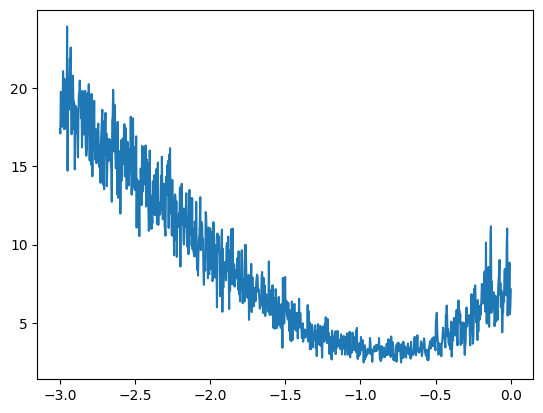

In [90]:
plt.plot(lri, lossi)

In [61]:
# making forward and backwards passes on the full dataset can take time and be onerous. 
# in practice batches are created and passes are on those subgroup of data
torch.randint(0, 5, (32,)) #return a batch of 32 random indexes between 0 and 5 
# for our case we need the indexes between 0 and X.shape[0]

tensor([4, 0, 4, 4, 1, 4, 2, 1, 2, 1, 0, 4, 0, 2, 0, 0, 2, 3, 4, 0, 2, 4, 0, 0,
        1, 0, 1, 4, 4, 4, 4, 0])

In [108]:
emb = C[X] # (32, 3, 2) # C[X] is on the full data set - we do it for comparison
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Y)
loss


tensor(2.3198, grad_fn=<NllLossBackward0>)

In [ ]:
# learning rate decay: reduce from factor 10 and run a few times more. 
# achieved loss 2.3 which is better than the one of the bigram before (2.5)
# increasing netywork -> overfitting: the model memorizes your training dataset so loss is very good - however, prediction not so good
# sampling will be always the same, like in the training dataset -> not a good éodel
# to avoid thatm dataset split up in 3: training split, dev/evaluation split and test split